# 06 · Las 10 preguntas ciegas (día 24)

**Qué cubre:** el contrato del enunciado (§4.5) — `responder()` y `evaluar()` ejecutables sobre un clon limpio, sin tocar código — y el entregable de la presentación "el resultado de las 10 preguntas ciegas, con su delta contra el golden set propio".

**El día 24 hay 20 minutos** para ejecutar `holdout.jsonl` (10 preguntas, mismo esquema que el golden propio, al menos 2 sin respuesta en el corpus) y llevar el resultado a la presentación. Este notebook es exactamente lo que se ejecuta ese día: tres celdas de trabajo, nada que escribir a mano salvo el nombre del fichero.

**Antes del 23, ensayarlo es obligatorio** (lo pide el propio enunciado). Con `MODO_ENSAYO = True` (la celda siguiente) corre sobre `golden/oficial_20.jsonl` en vez de `holdout.jsonl`, que tiene el mismo esquema y sirve de sustituto — es del profesor, así que el resultado sí importa, pero no es la nota final.

In [1]:
import os
import sys
import time
from pathlib import Path

RAIZ = Path.cwd() if (Path.cwd() / "agente").exists() else Path.cwd().parent
sys.path.insert(0, str(RAIZ))

import pandas as pd
from IPython.display import Markdown, display

if not os.environ.get("OPENROUTER_API_KEY"):
    from getpass import getpass
    os.environ["OPENROUTER_API_KEY"] = getpass("OPENROUTER_API_KEY: ")

from agente import evaluadores
from agente.agente import CONFIG_POR_DEFECTO
from agente.interfaz import evaluar

RES = RAIZ / "resultados"
print(f"Sistema que se va a evaluar (CONFIG_POR_DEFECTO): {CONFIG_POR_DEFECTO!r}")

Sistema que se va a evaluar (CONFIG_POR_DEFECTO): 'cifras_comparadas'


## El fichero de preguntas

`MODO_ENSAYO = True` usa `golden/oficial_20.jsonl` como sustituto de `holdout.jsonl`; en clase se cambia a `False`. `RUTA_HOLDOUT` es el único nombre de fichero que hay que tocar si el profesor lo entrega con otro nombre.

In [7]:
MODO_ENSAYO = True   # False el día 24, con holdout.jsonl ya en la raíz del repo
RUTA_HOLDOUT = RAIZ / "golden/oficial_20.jsonl" if MODO_ENSAYO else RAIZ / "holdout.jsonl"

if not RUTA_HOLDOUT.is_file():
    raise FileNotFoundError(
        f"No encuentro {RUTA_HOLDOUT}. Comprueba el nombre exacto del fichero "
        f"que ha entregado el profesor y actualiza RUTA_HOLDOUT.")

preguntas = evaluadores.cargar_golden(RUTA_HOLDOUT)
sin_campos = [p["id"] for p in preguntas if not {"id", "pregunta", "familia"} <= p.keys()]
assert not sin_campos, f"faltan campos básicos en: {sin_campos}"

print(f"{RUTA_HOLDOUT.name}: {len(preguntas)} preguntas")
familias = pd.Series([p["familia"] for p in preguntas]).value_counts()
display(familias.rename("preguntas"))
sin_cifra = sum(1 for p in preguntas if p["familia"] in ("numerica", "comparativa") and p.get("cifra_esperada") is None)
print(f"Preguntas sin cifra esperada (huecos del corpus): {sin_cifra}")

oficial_20.jsonl: 20 preguntas


numerica       7
comparativa    7
extractiva     6
Name: preguntas, dtype: int64

Preguntas sin cifra esperada (huecos del corpus): 0


## Ejecutar

Una sola llamada: `evaluar()` ya imprime el progreso pregunta a pregunta, el resumen y el desglose por familia, y guarda el detalle en `resultados/eval_<etiqueta>.csv` — es el mismo código que se probó en los notebooks 03, 04 y 05, no algo nuevo para hoy.

Se cronometra aparte porque el límite son 20 minutos: si al terminar quedan menos de 5, hay que ir directamente a leer el resultado y dejar el resto de la sesión para la presentación.

In [3]:
ETIQUETA = "ensayo_oficial" if MODO_ENSAYO else "holdout"

comienzo = time.time()
df = evaluar(str(RUTA_HOLDOUT), etiqueta=ETIQUETA)
minutos = (time.time() - comienzo) / 60

print(f"\nTiempo de la tirada: {minutos:.1f} min")
if not MODO_ENSAYO and minutos > 15:
    print("AVISO: quedan menos de 5 minutos de los 20 — ir directo a la lectura del resultado.")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

  ok  of-001      2.12c  cita=True cifra=None tool=True
  ok  of-002      1.00c  cita=True cifra=None tool=True
  ok  of-003      1.53c  cita=True cifra=None tool=True
  ok  of-004      1.23c  cita=True cifra=None tool=True
  ok  of-005      1.23c  cita=True cifra=None tool=True
  ok  of-006      0.92c  cita=True cifra=None tool=True
  ok  of-007      0.43c  cita=None cifra=True tool=True
  ok  of-008      0.75c  cita=None cifra=True tool=True
  ok  of-009      1.44c  cita=True cifra=True tool=True
  ok  of-010      1.44c  cita=None cifra=True tool=True
  ok  of-011      1.41c  cita=True cifra=True tool=True
  ok  of-012      0.69c  cita=None cifra=True tool=True
  ok  of-013      0.61c  cita=None cifra=True tool=True
  ok  of-014      2.02c  cita=True cifra=True tool=True
  ok  of-015      1.12c  cita=True cifra=True tool=True
  ok  of-016      1.56c  cita=True cifra=True tool=True
  ok  of-017      2.74c  cita=True cifra=True tool=True
  ok  of-018      2.40c  cita=True cifra=True to

## El delta contra el golden propio

Se compara con `resultados/eval_cifras_comparadas_propio.csv`, la tirada del sistema oficial sobre las 20 preguntas del golden propio (notebook 05) — es el número con el que se entrega el informe. **Si el hold-out sale peor, no es un suspenso: es el hallazgo que pide el enunciado.** Hay que poder decir qué parte de la mejora era general y cuál era memoria del conjunto con el que se iteró.

In [4]:
propio = pd.read_csv(RES / "eval_cifras_comparadas_propio.csv")
resumen_propio = evaluadores.resumir(propio, "golden propio (informe)")
resumen_holdout = evaluadores.resumir(df, "oficial (ensayo)" if MODO_ENSAYO else "holdout (10 ciegas)")

comparacion = pd.DataFrame([resumen_propio, resumen_holdout]).set_index("sistema")
COLUMNAS = {"cita_ok": "cita", "cifra_ok": "cifra", "tool_ok": "trayectoria", "recall@5": "recall@5",
            "coste_medio_¢": "coste (¢)", "latencia_media_s": "latencia (s)", "errores": "errores"}
comparacion = comparacion[list(COLUMNAS)].rename(columns=COLUMNAS)

delta = comparacion.diff().iloc[-1].round(3)
comparacion.loc["delta"] = delta

display(comparacion.round(3))

nombre = "ensayo_vs_propio" if MODO_ENSAYO else "holdout_vs_propio"
comparacion.round(3).to_csv(RES / f"{nombre}.csv")
print(f"Guardado: resultados/{nombre}.csv")

,cita,cifra,trayectoria,recall@5,coste (¢),latencia (s),errores
sistema,,,,,,,
golden propio (informe),0.929,0.923,1.0,0.923,2.076,25.862,0.0
oficial (ensayo),1.000,1.000,1.0,0.846,1.442,25.753,0.0
delta,0.071,0.077,0.0,-0.077,-0.634,-0.109,0.0


Guardado: resultados/ensayo_vs_propio.csv


## Para la presentación

- **La fila `delta`** de la tabla anterior es el número que va en la diapositiva: positivo es que el hold-out fue mejor que el golden propio, negativo que fue peor.
- **Antes de defenderlo, mira los errores** (`resultados/eval_<etiqueta>.csv`, columna `error`) y las preguntas concretas que fallaron: con solo 10 preguntas, una sola pesa un 10 % en cada métrica.
- **Al menos 2 de las 10 no tienen respuesta en el corpus.** Que el sistema conteste `fuente='ninguna'` sin cifra en esas es la mitad del examen, y se lee en la columna `cifra_ok` de esas filas.

## Figuras para el informe

Todo lo de aquí abajo sale de los CSV ya generados (`resultados/`) y de la tirada de arriba: **no llama a ningún modelo ni gasta nada**. Las figuras se guardan en `resultados/figuras/` (PNG a 200 ppp) para pegarlas en el PDF.

| Figura | Qué responde |
|---|---|
| 1 · Escalera de mejoras | ¿Qué aportó cada mejora (prompt, guardrails, búsqueda híbrida, cifras completas) sobre el baseline? |
| 2 · Coste y latencia | ¿Cuánto cuesta esa mejora en céntimos y segundos por pregunta? |
| 3 · Golden propio vs hold-out | ¿Se generaliza fuera del conjunto con el que se iteró? |
| 4 · Por familia | ¿Dónde falla el sistema: numéricas, extractivas o comparativas? |
| 5 · Pregunta a pregunta | ¿Qué se preguntó exactamente y cuál falló, en cada conjunto? |

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

FIG = RES / "figuras"
FIG.mkdir(exist_ok=True)

sns.set_theme(style="whitegrid", context="notebook")
COLORES = {"cita": "#2a78d6", "cifra": "#1baf7a", "recall@5": "#eb6834"}
plt.rcParams["figure.dpi"] = 110


def guardar(fig, nombre):
    ruta = FIG / f"{nombre}.png"
    fig.savefig(ruta, dpi=200, bbox_inches="tight")
    print(f"Guardada: {ruta.relative_to(RAIZ)}")

### Figura 1 · La escalera de mejoras

Cada peldaño añade una mejora sobre el anterior (`prompt v2` → `guardrails` → `híbrida` → `cifras completas`), medido sobre el golden propio y sobre el oficial (`tabla_baseline_vs_final_*.csv` del notebook 05). Un peldaño que baja es un hallazgo que hay que explicar en el informe, no esconder.

Guardada: resultados\figuras\fig1_escalera_mejoras.png


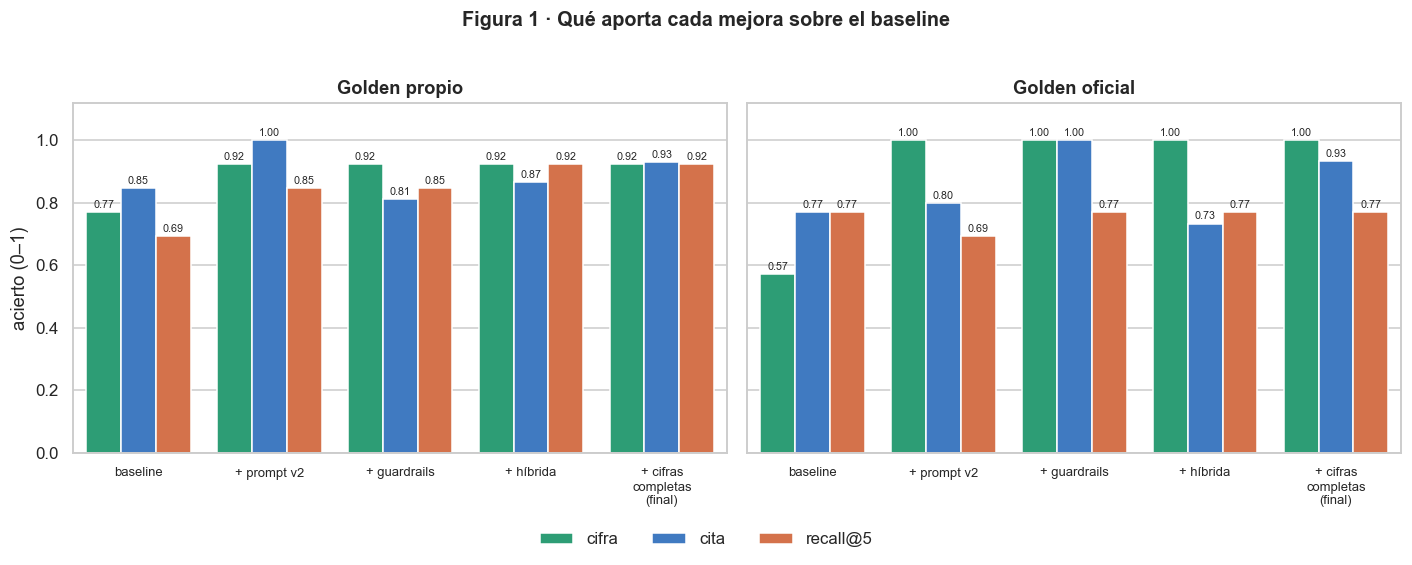

In [3]:
ORDEN = ["baseline", "+ prompt v2", "+ guardrails", "+ híbrida", "+ cifras completas (final oficial)"]
ETIQ = ["baseline", "+ prompt v2", "+ guardrails", "+ híbrida", "+ cifras\ncompletas\n(final)"]

tablas = {"Golden propio": pd.read_csv(RES / "tabla_baseline_vs_final_propio.csv").set_index("sistema").loc[ORDEN],
          "Golden oficial": pd.read_csv(RES / "tabla_baseline_vs_final_oficial.csv").set_index("sistema").loc[ORDEN]}

largo = pd.DataFrame([
    {"conjunto": conjunto, "sistema": sistema, "métrica": metrica, "valor": fila[metrica]}
    for conjunto, t in tablas.items() for sistema, fila in t.iterrows()
    for metrica in ("cifra", "cita", "recall@5")])

fig, ejes = plt.subplots(1, 2, figsize=(13, 4.6), sharey=True)
for eje, (conjunto, sub) in zip(ejes, largo.groupby("conjunto", sort=False)):
    sns.barplot(data=sub, x="sistema", y="valor", hue="métrica", order=ORDEN,
                hue_order=["cifra", "cita", "recall@5"], palette=COLORES, ax=eje, edgecolor="white")
    eje.set_title(conjunto, fontweight="bold")
    eje.set_xlabel("")
    eje.set_ylabel("acierto (0–1)" if eje is ejes[0] else "")
    eje.set_ylim(0, 1.12)
    eje.set_xticks(range(len(ORDEN)))
    eje.set_xticklabels(ETIQ, fontsize=8.5)
    for cont in eje.containers:
        eje.bar_label(cont, fmt="%.2f", fontsize=7, padding=1.5)
    manejas, etiquetas = eje.get_legend_handles_labels()
    eje.get_legend().remove()
fig.legend(manejas, etiquetas, loc="lower center", ncol=3, frameon=False, bbox_to_anchor=(0.5, -0.07))
fig.suptitle("Figura 1 · Qué aporta cada mejora sobre el baseline", fontsize=13, fontweight="bold", y=1.02)
fig.tight_layout()
guardar(fig, "fig1_escalera_mejoras")
plt.show()

### Figura 2 · Lo que cuesta cada mejora

Coste medio por pregunta (¢) y latencia media (s) sobre el golden propio: una mejora "vale la pena" si lo que sube el acierto compensa lo que sube el coste y el tiempo.

Guardada: resultados\figuras\fig2_coste_latencia.png


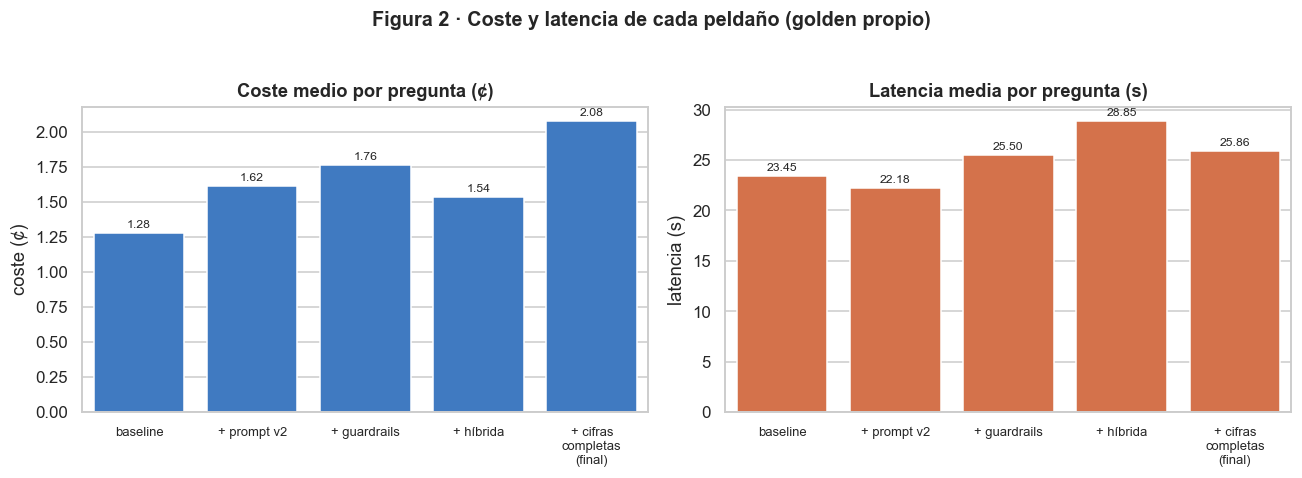

In [4]:
t = tablas["Golden propio"].reset_index()
t["etiqueta"] = ETIQ

fig, ejes = plt.subplots(1, 2, figsize=(12, 4.2))
sns.barplot(data=t, x="etiqueta", y="coste (¢)", ax=ejes[0], color="#2a78d6", edgecolor="white")
ejes[0].set_title("Coste medio por pregunta (¢)", fontweight="bold")
sns.barplot(data=t, x="etiqueta", y="latencia (s)", ax=ejes[1], color="#eb6834", edgecolor="white")
ejes[1].set_title("Latencia media por pregunta (s)", fontweight="bold")
for eje in ejes:
    eje.set_xlabel("")
    eje.tick_params(axis="x", labelsize=8.5)
    for cont in eje.containers:
        eje.bar_label(cont, fmt="%.2f", fontsize=8, padding=2)
fig.suptitle("Figura 2 · Coste y latencia de cada peldaño (golden propio)", fontsize=13, fontweight="bold", y=1.03)
fig.tight_layout()
guardar(fig, "fig2_coste_latencia")
plt.show()

### Figura 3 · Golden propio frente al hold-out

El sistema oficial sobre las preguntas con las que se iteró (golden propio) frente a las que no se habían visto (la tirada de arriba, `df`). Con `MODO_ENSAYO = True` el segundo conjunto es el ensayo con `oficial_20.jsonl` y la figura lo indica en el título; con el hold-out real (`MODO_ENSAYO = False`) se etiqueta como hold-out.

Guardada: resultados\figuras\fig3_propio_vs_holdout.png


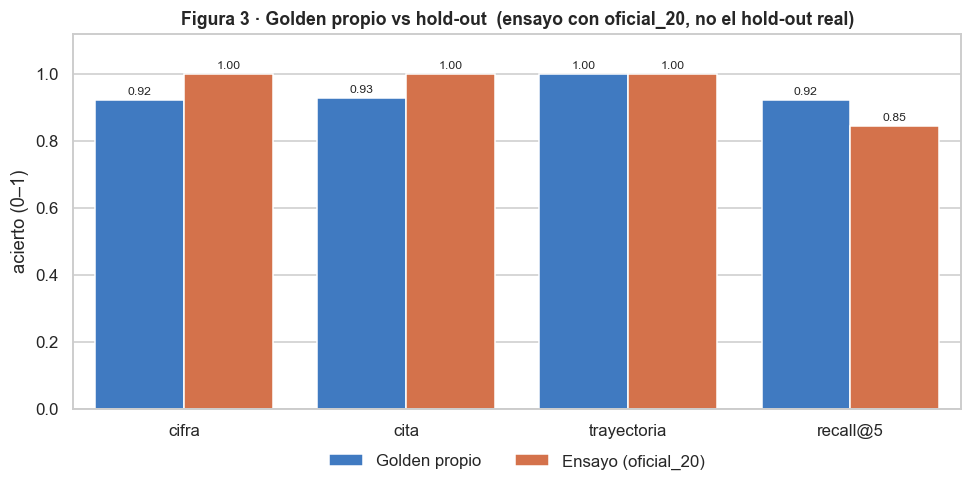

Delta (segundo conjunto − golden propio):
cifra          0.077
cita           0.071
trayectoria    0.000
recall        -0.077


In [5]:
NOMBRE_H = "Ensayo (oficial_20)" if MODO_ENSAYO else "Hold-out (10 ciegas)"

propio_f = propio.assign(conjunto="Golden propio")
hold_f = df.assign(conjunto=NOMBRE_H)
todo = pd.concat([propio_f, hold_f], ignore_index=True)


def tasa(serie):
    limpia = serie.dropna().astype(float)
    return limpia.mean() if len(limpia) else float("nan")


resumen = (todo.groupby("conjunto")
               .agg(cifra=("cifra_ok", tasa), cita=("cita_ok", tasa),
                    trayectoria=("tool_ok", tasa), recall=("recall", tasa))
               .reindex(["Golden propio", NOMBRE_H]))
largo3 = (resumen.rename(columns={"recall": "recall@5"}).reset_index()
                 .melt(id_vars="conjunto", var_name="métrica", value_name="valor"))

fig, eje = plt.subplots(figsize=(9, 4.6))
sns.barplot(data=largo3, x="métrica", y="valor", hue="conjunto",
            palette=["#2a78d6", "#eb6834"], ax=eje, edgecolor="white")
eje.set_ylim(0, 1.12)
eje.set_xlabel("")
eje.set_ylabel("acierto (0–1)")
for cont in eje.containers:
    eje.bar_label(cont, fmt="%.2f", fontsize=8, padding=2)
eje.legend(title="", loc="upper center", bbox_to_anchor=(0.5, -0.08), ncol=2, frameon=False)
sufijo = "  (ensayo con oficial_20, no el hold-out real)" if MODO_ENSAYO else ""
eje.set_title(f"Figura 3 · Golden propio vs hold-out{sufijo}", fontweight="bold", fontsize=11.5)
fig.tight_layout()
guardar(fig, "fig3_propio_vs_holdout")
plt.show()

print("Delta (segundo conjunto − golden propio):")
print((resumen.loc[NOMBRE_H] - resumen.loc["Golden propio"]).round(3).to_string())

### Figura 4 · Por familia de pregunta

El desglose que pide el enunciado: acierto de cifra y de cita en cada familia, golden propio frente al segundo conjunto. `cifra` no aplica a las extractivas (no tienen cifra esperada), así que ahí solo hay barras de cita. Con 10–20 preguntas por conjunto, una sola pregunta mueve una barra entre 5 y 10 puntos: no hay que sobreinterpretar diferencias pequeñas.

Guardada: resultados\figuras\fig4_por_familia.png


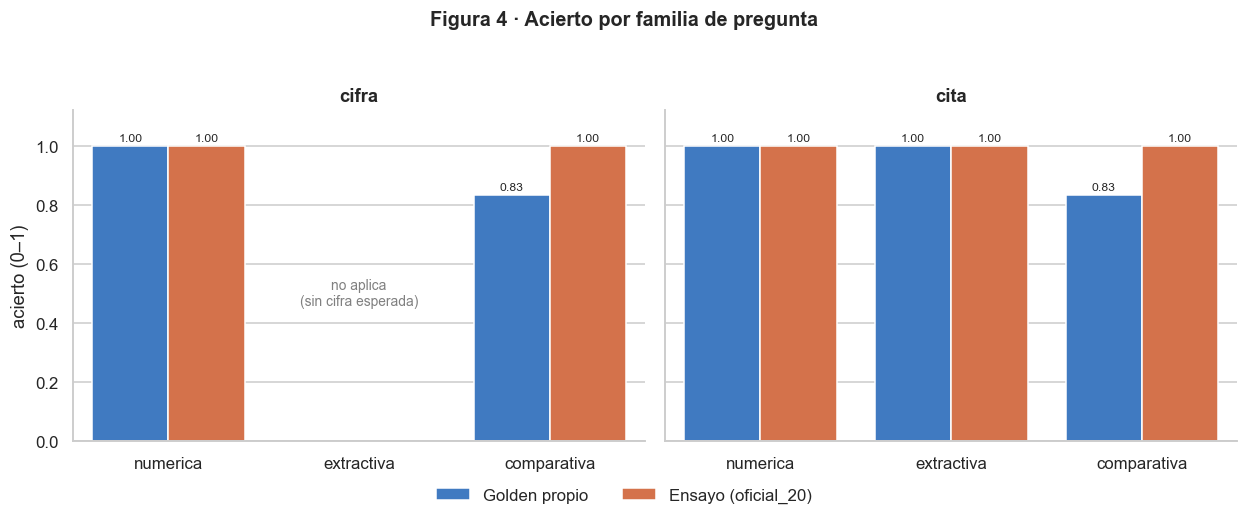

In [6]:
por_familia = (todo.melt(id_vars=["conjunto", "familia"], value_vars=["cifra_ok", "cita_ok"],
                         var_name="métrica", value_name="ok")
                    .dropna(subset=["ok"]))
por_familia["ok"] = por_familia["ok"].astype(float)
por_familia["métrica"] = por_familia["métrica"].map({"cifra_ok": "cifra", "cita_ok": "cita"})

g = sns.catplot(data=por_familia, x="familia", y="ok", hue="conjunto", col="métrica",
                kind="bar", order=["numerica", "extractiva", "comparativa"],
                hue_order=["Golden propio", NOMBRE_H], palette=["#2a78d6", "#eb6834"],
                errorbar=None, height=4.2, aspect=1.15, edgecolor="white", sharey=True)
g.set(ylim=(0, 1.12))
sns.move_legend(g, "lower center", bbox_to_anchor=(0.5, -0.06), ncol=2, title=None, frameon=False)
g.axes.flat[0].text(1, 0.5, "no aplica\n(sin cifra esperada)", ha="center", va="center", color="gray", fontsize=9)
g.set_axis_labels("", "acierto (0–1)")
g.set_titles("{col_name}", fontweight="bold")
for eje in g.axes.flat:
    for cont in eje.containers:
        eje.bar_label(cont, fmt="%.2f", fontsize=8, padding=2)
g.figure.suptitle("Figura 4 · Acierto por familia de pregunta", fontsize=13, fontweight="bold", y=1.04)
g.figure.tight_layout()
guardar(g.figure, "fig4_por_familia")
plt.show()

### Figura 5 · Pregunta a pregunta: qué se preguntó y qué salió

Las figuras anteriores dan porcentajes; esta enseña **cada pregunta** con su resultado en las cuatro métricas (verde ✔ bien, rojo ✘ mal, gris = no aplica a esa pregunta), agrupadas por familia. Así, cuando el informe diga "falla", se ve exactamente cuál y en qué. `recall@5` mide la búsqueda (¿trajo el fragmento correcto entre los 5 primeros?), no la respuesta: una ✘ ahí con cifra ✔ significa que el agente acertó por otro camino.

Guardada: resultados\figuras\fig5a_preguntas_golden_propio.png


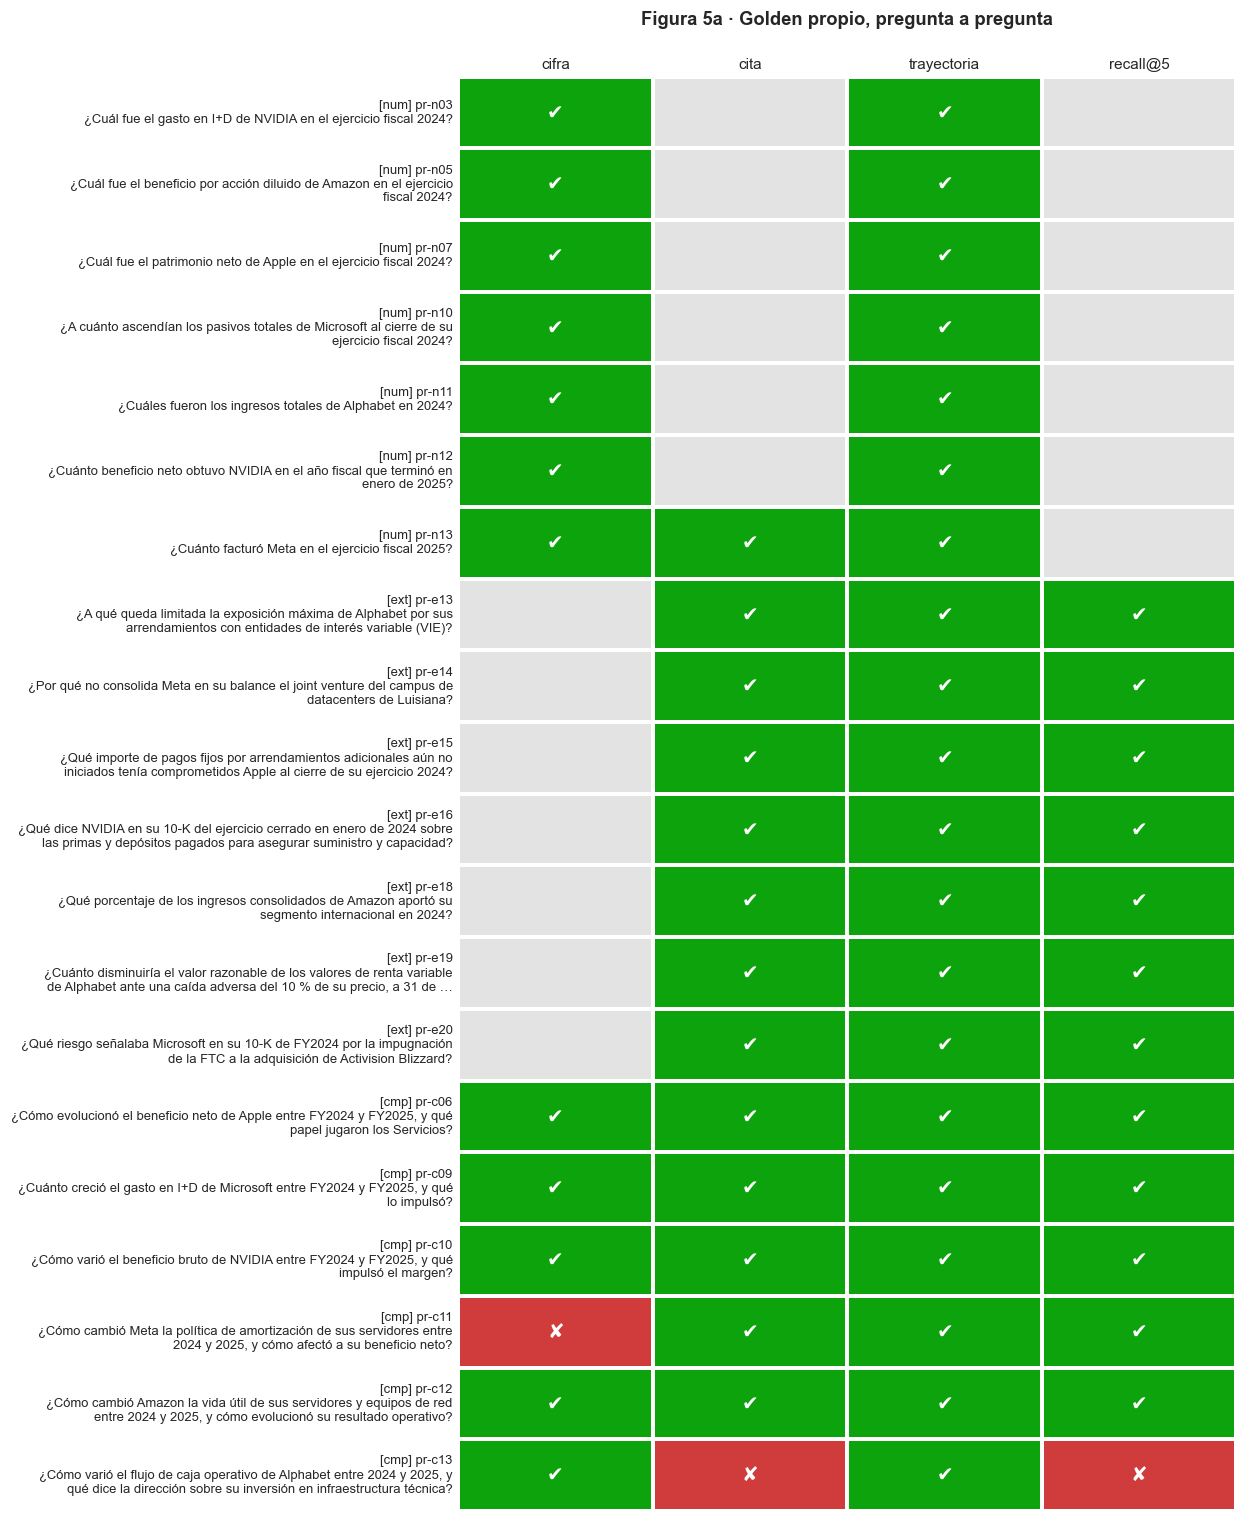

Guardada: resultados\figuras\fig5b_preguntas_holdout.png


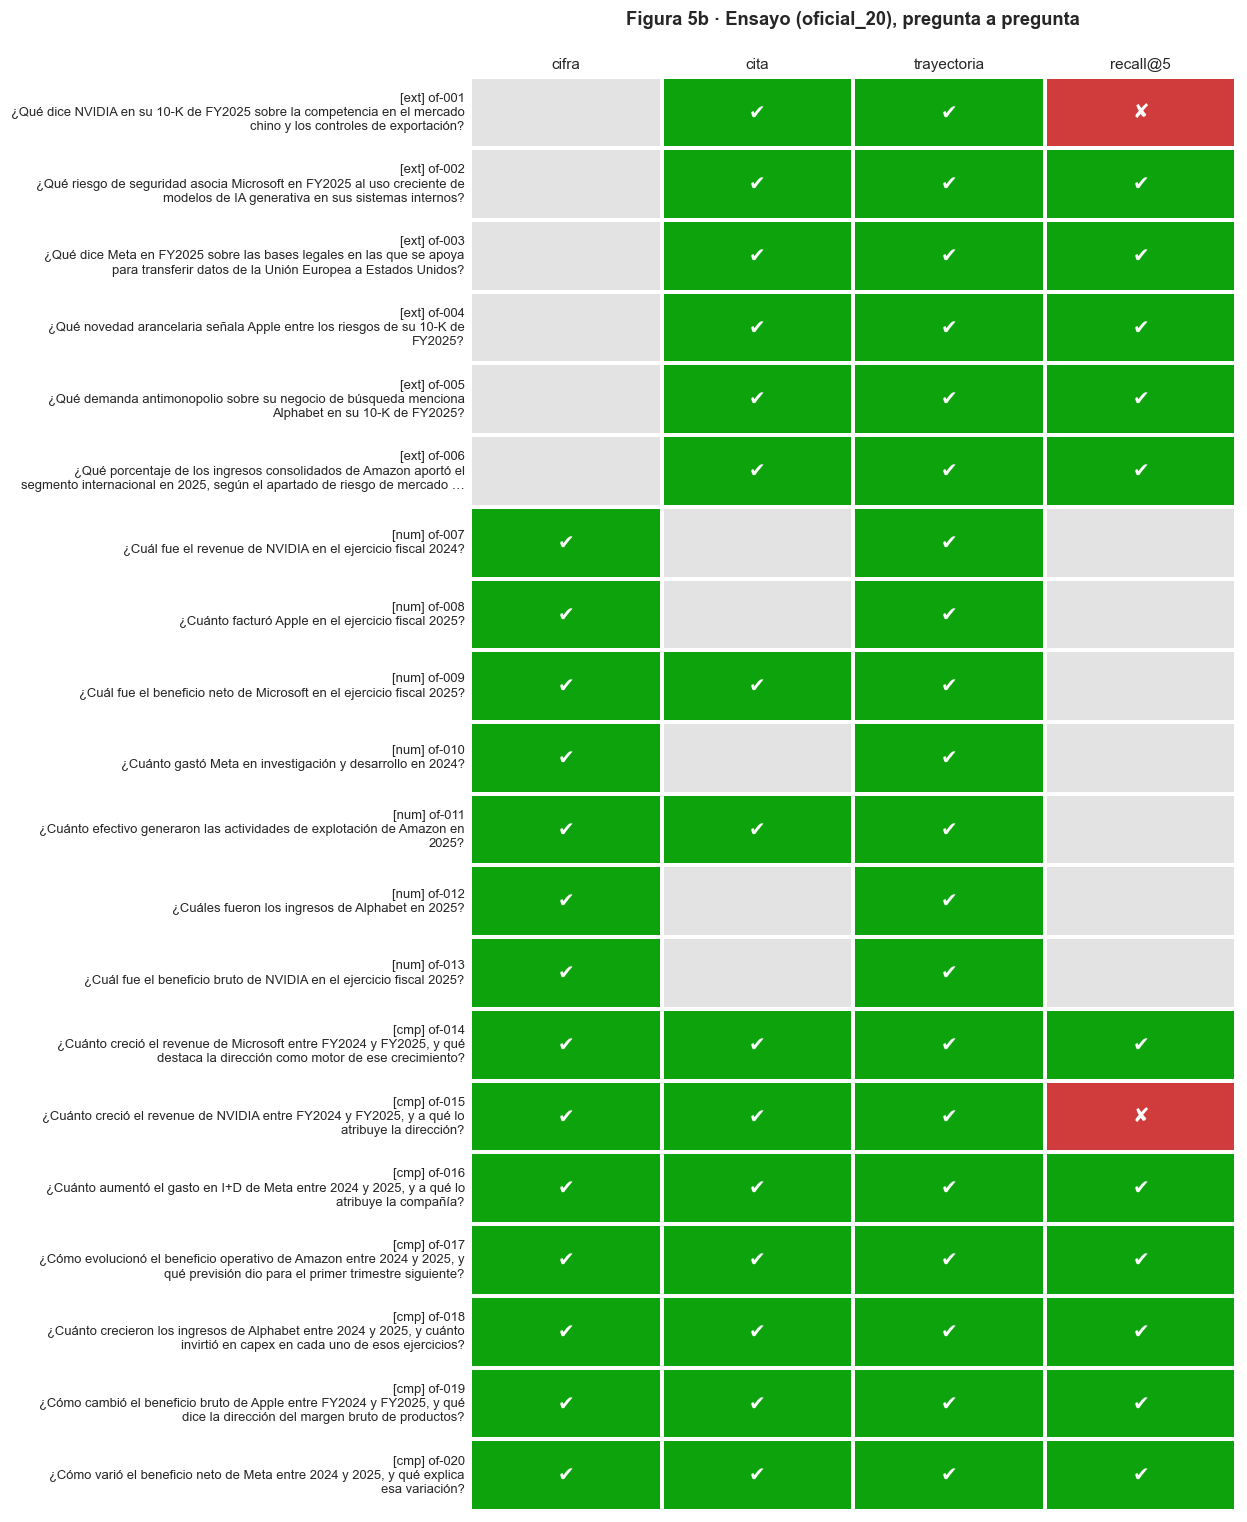

In [7]:
import textwrap

from matplotlib.colors import ListedColormap

GOLDEN_PROPIO = evaluadores.cargar_golden(RAIZ / "golden" / "golden_set.jsonl")
COLS = [("cifra_ok", "cifra"), ("cita_ok", "cita"), ("tool_ok", "trayectoria"), ("recall", "recall@5")]
ABREV = {"numerica": "num", "extractiva": "ext", "comparativa": "cmp"}
PALETA = ListedColormap(["#d03b3b", "#0ca30c"])   # 0 = mal, 1 = bien (los n/a se pintan aparte)


def _bool(x):
    return {"True": 1.0, "False": 0.0}.get(str(x), float("nan"))


def mapa_preguntas(resultados, golden, titulo, nombre):
    texto = {p["id"]: p["pregunta"] for p in golden}
    m = resultados.copy()
    def _etiqueta(i, f):
        lineas = textwrap.wrap(texto.get(i, "?"), 72, max_lines=2, placeholder=" …")
        return f"[{ABREV.get(f, f)}] {i}\n" + "\n".join(lineas)

    m["etiqueta"] = [_etiqueta(i, f) for i, f in zip(m["id"], m["familia"])]
    valores = pd.DataFrame({nom: m[col].map(_bool) for col, nom in COLS}).set_axis(m["etiqueta"])
    marcas = valores.map(lambda v: "" if pd.isna(v) else ("✔" if v == 1 else "✘"))

    fig, eje = plt.subplots(figsize=(11.5, 0.62 * len(valores) + 1.6))
    eje.set_facecolor("#e3e3e3")                      # las celdas n/a (NaN) quedan en gris
    eje.grid(False)                                   # sin rejilla del tema sobre las celdas grises
    sns.heatmap(valores, cmap=PALETA, vmin=0, vmax=1, annot=marcas, fmt="", cbar=False,
                linewidths=2.5, linecolor="white",
                annot_kws={"fontsize": 13, "color": "white", "fontweight": "bold", "fontfamily": "DejaVu Sans"},
                ax=eje)
    eje.xaxis.tick_top()
    eje.tick_params(axis="x", labelsize=10, length=0)
    eje.tick_params(axis="y", labelsize=8.5, length=0)
    eje.set_ylabel("")
    eje.set_title(titulo, fontweight="bold", fontsize=12, pad=34)
    fig.tight_layout()
    guardar(fig, nombre)
    plt.show()


mapa_preguntas(propio, GOLDEN_PROPIO,
               "Figura 5a · Golden propio, pregunta a pregunta", "fig5a_preguntas_golden_propio")
mapa_preguntas(df, preguntas,
               f"Figura 5b · {NOMBRE_H}, pregunta a pregunta", "fig5b_preguntas_holdout")

In [8]:
textos = {p["id"]: p for p in GOLDEN_PROPIO + preguntas}

def fallos_de(resultados, conjunto):
    filas = []
    for _, r in resultados.iterrows():
        mal = [nom for col, nom in COLS if _bool(r[col]) == 0.0]
        if not mal:
            continue
        p = textos.get(r["id"], {})
        filas.append({"conjunto": conjunto, "id": r["id"], "familia": r["familia"],
                      "falla": ", ".join(mal), "pregunta": p.get("pregunta", "?"),
                      "cifra esperada": p.get("cifra_esperada"), "cifra del agente": r["cifra_agente"]})
    return pd.DataFrame(filas)


fallos = pd.concat([fallos_de(propio, "Golden propio"), fallos_de(df, NOMBRE_H)], ignore_index=True)
print(f"{len(fallos)} preguntas con alguna ✘ (de {len(propio) + len(df)}):\n")
with pd.option_context("display.max_colwidth", 95, "display.width", 200):
    display(fallos)

4 preguntas con alguna ✘ (de 40):



,conjunto,id,familia,falla,pregunta,cifra esperada,cifra del agente
0,Golden propio,pr-c11,comparativa,cifra,"¿Cómo cambió Meta la política de amortización de sus servidores entre 2024 y 2025, y cómo a...",6.045800e+10,2.590000e+09
1,Golden propio,pr-c13,comparativa,"cita, recall@5","¿Cómo varió el flujo de caja operativo de Alphabet entre 2024 y 2025, y qué dice la direcci...",1.647130e+11,1.647130e+11
2,Ensayo (oficial_20),of-001,extractiva,recall@5,¿Qué dice NVIDIA en su 10-K de FY2025 sobre la competencia en el mercado chino y los contro...,NaN,NaN
3,Ensayo (oficial_20),of-015,comparativa,recall@5,"¿Cuánto creció el revenue de NVIDIA entre FY2024 y FY2025, y a qué lo atribuye la dirección?",1.304970e+11,1.304970e+11


In [ ]:
print("NOTEBOOK 06 COMPLETADO.")
print(f"Modo: {'ENSAYO (golden/oficial_20.jsonl)' if MODO_ENSAYO else 'HOLD-OUT REAL'}")
print(f"Resultado detallado: resultados/eval_{ETIQUETA}.csv")
print(f"Delta contra el golden propio: resultados/{'ensayo_vs_propio' if MODO_ENSAYO else 'holdout_vs_propio'}.csv")
print(f"Figuras para el informe: {[f.name for f in sorted(FIG.glob('*.png'))]}")